# Visualiza las zonas de sombra por relieve durante el eclipse de 2026

## 0 Introducción

En este notebook se describe el código en Python necesario para la realización del ejercicio de datos que muestra las **zonas de sombra por relieve** para el eclipse de 2026 sobre la península ibérica.

Los pasos a ejecutar son los siguientes:
- **Lectura del fichero** de entrada
- **Cambio de coordenadas**
- **Recorte de los datos de entrada** acorde con el perímetro de un municipio
- Creación de un mapa en Python con los **resultados parciales y definitivos** sobre el municipio estudiado
- Exportar la zona de sombra como un **fichero .geojson**

Tras la realización de estos pasos seremos capaces de familiarizarnos con el **formato .TIFF**, la estructuración de datos georreferenciados en **formato pandas y geopandas**, las herramientas básicas para realizar **recorte o clipping** de formas geométricas y finalmente el uso de librerías de Python para **crear mapas** y hacer una rápida comprobación de los resultados de nuestras operaciones.



## 1. Proceso de desarrollo

En esta sección veremos las diferentes etapas a cubrir para llegar desde el fichero comprimido original hasta desplegar mapas en diversas plataformas con la información relevante del eclipse total.

### 1.1 Lectura de un fichero TIF

Para la lectura del TIFF utilizaremos la libreria Rioxarray de Python, que nos permite volcar el contenido de un TIFF en un xarray, un array tradicional para datos georreferenciados.

Lo primero que haremos será importar todas las librerías de Python necesarias para el desarrollo de esta parte del ejercicio.

In [ ]:
!pip install rioxarray
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr
import geopandas as gpd
from shapely.geometry import mapping
from rasterio.crs import CRS
import xarray as xr
import io
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Una vez hemos incorporado las librerías necesarias descargamos el fichero terrain_shadows_2026_3857_COG_DEF_OVERSx6_8704x8192.tif del CNIG con la información referente a la zona de sombra por relieve, bien a través del enlace descrito en el ejercicio o desde el repositorio de Github. Una vez descargado subimos el fichero a través de la función .upload() del notebook.

In [ ]:
uploaded = files.upload()

Saving terrain_shadows_2026_3857_COG_DEF_OVERSx6_8704x8192.tif to terrain_shadows_2026_3857_COG_DEF_OVERSx6_8704x8192.tif


Leemos el fichero con rioxarray y lo almacenamos en la variable raster:

In [ ]:
raster = rxr.open_rasterio(io.BytesIO(uploaded['terrain_shadows_2026_3857_COG_DEF_OVERSx6_8704x8192.tif']))

A continuación subimos el fichero SHP con la información relativa al municipio donde queremos estudiar las zonas de sombra por relieve:

In [ ]:
uploaded = files.upload()

Saving MUNICIPIOS_5000_ETRS89.cpg to MUNICIPIOS_5000_ETRS89.cpg
Saving MUNICIPIOS_5000_ETRS89.dbf to MUNICIPIOS_5000_ETRS89.dbf
Saving MUNICIPIOS_5000_ETRS89.prj to MUNICIPIOS_5000_ETRS89.prj
Saving MUNICIPIOS_5000_ETRS89.shp to MUNICIPIOS_5000_ETRS89.shp
Saving MUNICIPIOS_5000_ETRS89.shx to MUNICIPIOS_5000_ETRS89.shx


Una vez hemos subido el fichero lo leemos con la ayuda de la librería geopandas:

In [ ]:
crop_extent_orig=gpd.read_file('MUNICIPIOS_5000_ETRS89.shp')

### 1.2 Cambio de CRS
Las capas tanto de la información de las zonas de sombra como de los límites del municipio ya están disponibles. Realizamos a continuación un cambio de coordenadas, para asegurarnos de que ambas capas operan en el mismo sistema y que por lo tanto podemos aplicar procesos de solape y recorte sin problemas.
Verificamos entonces en qué sistema de coordenadas tenemos las diferentes capas.

In [ ]:
crop_extent_orig.crs

<Projected CRS: EPSG:25830>
Name: ETRS89 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°W and 0°W: Faroe Islands offshore; Ireland - offshore; Jan Mayen - offshore; Norway including Svalbard - offshore; Spain - mainland - onshore and offshore.
- bounds: (-6.0, 35.26, 0.01, 80.49)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Observamos cómo el CRS corresponde al EPSG:25830. Veamos ahora el CRS del raster de sombras utilizando la librería rioxarray:

In [ ]:
raster.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

En este caso es WGS84. Para poder operar con ambas redefinimos los correspondientes CRS y reproyectamos en el más popular y comúnmente utilizado EPSG:4326.

In [ ]:
raster_new = raster[0].rio.reproject(CRS.from_string('EPSG:4326'))
crop_extent = crop_extent_orig.to_crs('EPSG:4326')

### 1.3 Seleccion de municipio

Una vez tenemos ambas capas en el mismo sistema de coordendas seleccionamos el primer municipio, el correspondiente por lo tanto al elemento 0 de todos los polígonos que nos ofrece el SHP de municipios del País Vasco.

In [ ]:
crop_extent = crop_extent.iloc[[0]]

### 1.4 Clipping

Realizamos a continuación el recorte de las zonas de sombra sobre el municipio seleccionado aplicando la función clip y utilizando de argumentos el municipio seleccionado y el raster de sombras

In [ ]:
clipped = raster_new.rio.clip(crop_extent.geometry.apply(mapping),crop_extent.crs)

Para poder ver el resultado realizamos igualmente dos operaciones. La primera es invertir la capa, ya que la lectura se realiza de forma inversa. Y eliminamos también todos los valores fuera de la zona de estudio asignando un NaN a la salida del producto etiquetada como 61 y que no se corresponde a información relacionada con la zona de sombra.

In [ ]:
raster_plot = np.flipud(raster_new)
raster_plot[raster_plot == 61] = 0
clippped = np.flipud(clipped)
clipped = clipped.where(clipped != 61)

### 1.5 Mapa de los datos

En primer lugar observamos la información del fichero producido por el CNIG. En él apreciamos la extensión geográfica del fichero, las diferentes zonas de sombra por relieve así como la sombra generada por la oscuridad de la noche en la zona oriental de la imagen.

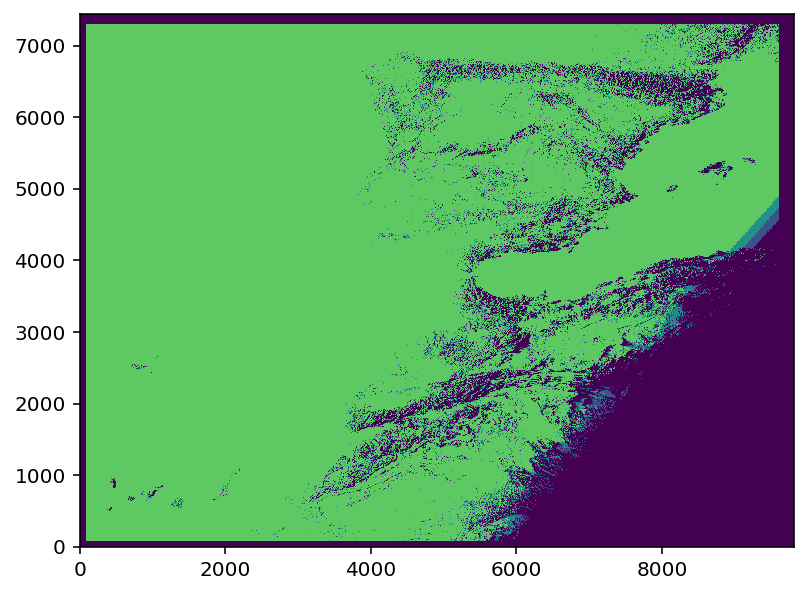

In [ ]:
fig,ax = plt.subplots(dpi=144)
ax.pcolormesh(raster_plot)
plt.show()


El perfil del SHP del municipio de Amurrio se puede ver en la siguiente imagen. Con la función .plot podemos dibujar el contorno del municipio, y la zona sobre la que realizaremos el recorte del fichero de la zona de sombra.

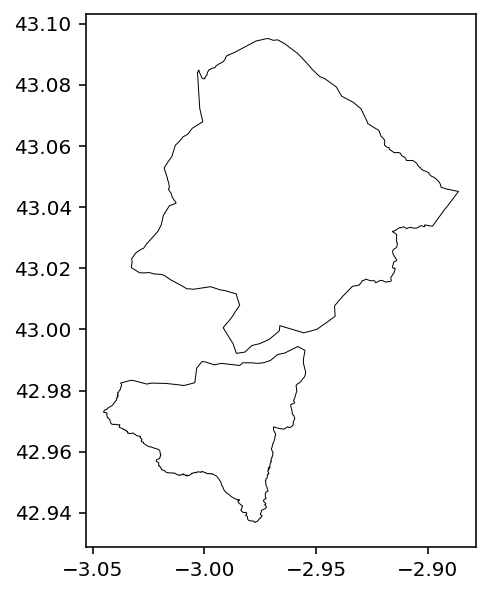

In [ ]:
fig,ax = plt.subplots(dpi=144)
crop_extent.plot(ax=ax, facecolor='none',edgecolor='black',linewidth=0.5);
plt.show()

Por último tenemos el resultado del recorte sobre el fichero de la zona de sombra. Obtenemos así los diferentes valores en el municipio de Amurrio, que ofrece la variedad deseada para mostrar que en un mismo municipio el cálculo de sombra presenta todo el espectro de posibilidades.

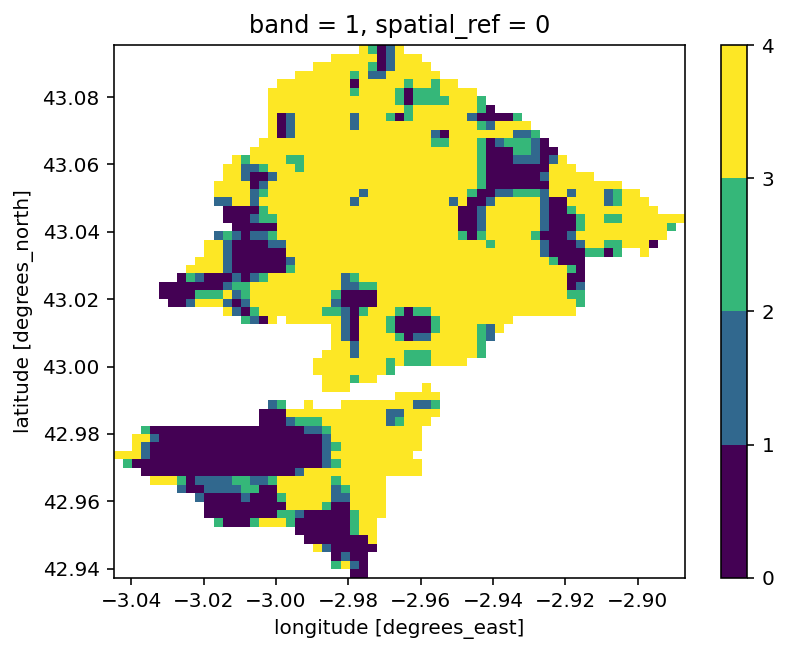

In [ ]:
fig,ax = plt.subplots(dpi=144)
clipped.plot(levels=[0,1,2,3,4])
plt.show()

### 1.6 Creación del GeoJSON a través de un dataframe

Para poder representar la información de las zonas de sombra en un municipio en concreto sobre otros soportes que no sean Python, exportamos el resultado visto anteriormente sobre un fichero geojson, que nos permitirá utilizar otros lenguajes como Javascript para su visualización.

In [ ]:
clipped = xr.Dataset({"shadow": clipped})
neu = clipped.to_dataframe().reset_index()
gdf = gpd.GeoDataFrame(neu.shadow, geometry=gpd.points_from_xy(neu.x,neu.y))
gdf.to_file(r"./clipped.geojson", driver='GeoJSON')